# Replication of the paper - Virtue of Complexity everywhere

In [1]:
pip install autograd

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pymanopt

Note: you may need to restart the kernel to use updated packages.


In [15]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

import numpy as np
from matplotlib import pyplot as plt

import autograd.numpy as anp
from pymanopt import Problem
from pymanopt.manifolds import Grassmann
from pymanopt.function import autograd as pymanopt_autograd
from pymanopt.optimizers import ConjugateGradient, SteepestDescent, TrustRegions

import requests
import zipfile
import io
import os
import sys
from pathlib import Path

In [ ]:
from pathlib import Path
import sys
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from src.IPCA_Grass_estimator import GrassmannManifoldIPCAEstimator
from src.rff import RandomFourierFeatures

## Working with stock level return + characteristics prediction

In [18]:
#These charactereistics dont have much variance in them, making the problem illposed, lets load the return data for these stock from 2020 - 2026 and create our our characteristics using the return data, and then we will use the IPCA approach to predict the return of stocks. We will perform the same for a bigger period later

df_returns = pd.read_excel("df_data_all_stocks_2020_onwards.xlsx")
df_returns.rename(columns={'yyyymm': 'date'}, inplace=True)

In [19]:
df_returns.head()
# lets pivot the table to have permno and date as index, and all the columns as values, and then we will use this data to create our characteristics for the IPCA approach. We will use the return data to create momentum and volatility characteristics for each stock, and then we will use these characteristics to predict the return of stocks using the IPCA approach.

df_returns = df_returns.pivot_table(index=['permno', 'date'], values=[col for col in df_returns.columns if col not in ['permno', 'date']], aggfunc='first')
df_returns.head()

AM       AOP  AbnormalAccruals  Accruals  AccrualsBM  \
permno date                                                                     
10026  2020-01-01  0.297053  0.140903         -0.036085  0.029798         NaN   
       2020-02-01  0.306326  0.140903         -0.036085  0.029798         NaN   
       2020-03-01  0.446013  0.140903          0.005110  0.040243         NaN   
       2020-04-01  0.424841  0.140903          0.005110  0.040243         NaN   
       2020-05-01  0.419556  0.140903          0.005110  0.040243         NaN   

                      AdExp  AnalystRevision  AnalystValue  \
permno date                                                  
10026  2020-01-01  0.001650         1.000000      0.286805   
       2020-02-01  0.001701         0.973129      0.286805   
       2020-03-01  0.002598         0.909270      0.286805   
       2020-04-01  0.002475         0.976139      0.286805   
       2020-05-01  0.002444         0.291111      0.286805   

                   AnnouncementReturn  AssetGrowth  ...      roaq  sfe  \
permno date                                         ...                  
10026  2020-01-01           -0.092029    -0.074704  ...  0.026180  NaN   
       2020-02-01           -0.092029    -0.074704  ...  0.026180  NaN   
       2020-03-01           -0.092029    -0.093696  ...  0.016735  NaN   
       2020-04-01            0.026064    -0.093696  ...  0.016735  NaN   
       2020-05-01            0.026064    -0.093696  ...  0.016735  NaN   

                   sinAlgo     skew1  std_turn      tang  year  zerotrade12M  \
permno date                                                                    
10026  2020-01-01      0.0 -0.050505       NaN  0.710366  2020  8.212433e-08   
       2020-02-01      0.0 -0.031910       NaN  0.710366  2020  8.174433e-08   
       2020-03-01      0.0  0.235420       NaN  0.755241  2020  8.005990e-08   
       2020-04-01      0.0 -0.142723       NaN  0.755241  2020  7.113406e-08   
       2020-05-01      0.0  0.020169       NaN  0.755241  2020  6.537433e-08   

                    zerotrade1M   zerotrade6M  
permno date                                    
10026  2020-01-01  2.013817e-08  1.457501e-07  
       2020-02-01  1.756096e-08  1.399235e-07  
       2020-03-01  2.336111e-08  1.452774e-07  
       2020-04-01  9.570691e-09  1.271560e-07  
       2020-05-01  1.103157e-08  1.143823e-07  

[5 rows x 207 columns]

In [20]:
#lets see how the data looks like for a few more columns, thigs arebeing truncated in.head()

# we need to see more columns i.e, horizontal view
with pd.option_context("display.max_columns", None, "display.width", 50, "display.max_colwidth", None):
    print(df_returns.loc[10104].head(10).to_string())

                  AM  AOP  AbnormalAccruals  Accruals  AccrualsBM     AdExp  AnalystRevision  AnalystValue  AnnouncementReturn  AssetGrowth  BM     BMdec     BPEBM      Beta    BetaFP  BetaLiquidityPS  BetaTailRisk  BidAskSpread  BookLeverage  BrandInvest  CBOperProf        CF  CPVolSpread      Cash  CashProd  ChAssetTurnover      ChEQ  ChForecastAccrual     ChInv   ChInvIA  ChNAnalyst   ChNNCOA     ChNWC     ChTax  ChangeInRecommendation  CitationsRD  CompEquIss  CompositeDebtIssuance  ConsRecomm  ConvDebt  CoskewACX  Coskewness  CredRatDG  CustomerMomentum  DebtIssuance  DelBreadth    DelCOA    DelCOL    DelDRC    DelEqu   DelFINL  DelLTI  DelNetFin  DivInit  DivOmit  DivSeason  DivYieldST     DolVol  DownRecomm       EBM        EP  EarnSupBig  EarningsConsistency  EarningsForecastDisparity  EarningsStreak  EarningsSurprise    EntMult  EquityDuration  ExchSwitch  ExclExp  FEPS  FR  FirmAge  ForecastDispersion  Frontier       GP   GrAdExp   GrLTNOA  GrSaleToGrInv  GrSaleToGrOverhead  

In [21]:
char_feats = [ 'Beta', 'skew1',  'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD']
# lets work with just these 4 features for now, we will extend to all the features later
df_trunc = df_returns[char_feats + ['Price']]
#create a return column from the price, shift the returns by 1 so that there is no look ahead

df_trunc['ret'] = df_trunc.groupby(level=0)['Price'].pct_change()
df_trunc['ret'] = df_trunc['ret'].shift(-1)
df_trunc.dropna(inplace=True)
df_trunc.head()

Beta     skew1     Mom6m  RealizedVol   betaVIX  \
permno date                                                              
10026  2020-01-01  0.212075 -0.050505 -0.002764    -0.025857 -0.003299   
       2020-02-01  0.227315 -0.031910 -0.136068    -0.012975  0.002487   
       2020-03-01  0.553396  0.235420 -0.159782    -0.079814  0.000614   
       2020-04-01  0.517375 -0.142723 -0.360692    -0.046392 -0.000792   
       2020-05-01  0.507410  0.020169 -0.307936    -0.039382 -0.012214   

                    zerotrade6M     VolSD     Price       ret  
permno date                                                    
10026  2020-01-01  1.457501e-07 -0.307756 -5.111023 -0.006014  
       2020-02-01  1.399235e-07 -0.308896 -5.080286 -0.056000  
       2020-03-01  1.452774e-07 -0.500634 -4.795791  0.010141  
       2020-04-01  1.271560e-07 -0.591220 -4.844423  0.002584  
       2020-05-01  1.143823e-07 -0.612271 -4.856940 -0.002415

In [ ]:

# def run_ipca_grass(
#     df_trunc,
#     char_feats,
#     num_fact=2,
#     window_len=12,
#     max_nan=0.3,
#     max_zero=0.3,
#     min_non_nan_frac=0.7,
# ):
#     #Lets perform IPCA_Grass_estimation ont this data, we use char_feats to creae our characterstics, and do a rolling backtest where we fit the model for the last 12 months
#     # and then try to predict the return for the next month, and then we will evaluate the performance of the model using mean squared error and R2 score. 
#     # Diagnose zeros/NaNs and rebuild panel to reduce singularity issues

#     # Build stock-level panel from df_trunc
#     df_panel = df_trunc.copy().sort_index()

#     # Returns panel (T, N)
#     rets_panel = df_panel["ret"].unstack("permno").sort_index()

#     # Lagged characteristics panels (T, N) for each feature
#     X_list = []
#     for col in char_feats:
#         x = df_panel[col].unstack("permno").sort_index()
#         x = x.shift(1)
#         X_list.append(x)

#     # Align assets across all panels
#     common_assets = rets_panel.columns
#     for x in X_list:
#         common_assets = common_assets.intersection(x.columns)

#     rets_panel = rets_panel[common_assets]
#     X_list = [x[common_assets] for x in X_list]

#     # Diagnose missing/zeros
#     zero_frac_rets = (rets_panel == 0).mean()
#     nan_frac_rets = rets_panel.isna().mean()
#     #print("rets zero frac (top 5):", zero_frac_rets.sort_values(ascending=False).head())
#     #print("rets nan  frac (top 5):", nan_frac_rets.sort_values(ascending=False).head())

#     # Drop assets with too many missing/zeros in returns or any characteristic
#     good_assets = (nan_frac_rets <= max_nan) & (zero_frac_rets <= max_zero)
#     for x in X_list:
#         good_assets &= (x.isna().mean() <= max_nan)
#         good_assets &= ((x == 0).mean() <= max_zero)

#     rets_panel = rets_panel.loc[:, good_assets]
#     X_list = [x.loc[:, good_assets] for x in X_list]

#     # Drop early rows with heavy NaNs (burn-in)
#     min_non_nan = int(min_non_nan_frac * rets_panel.shape[1])
#     valid_time = rets_panel.notna().sum(axis=1) >= min_non_nan
#     for x in X_list:
#         valid_time &= (x.notna().sum(axis=1) >= min_non_nan)

#     rets_panel = rets_panel.loc[valid_time]
#     X_list = [x.loc[valid_time] for x in X_list]

#     # Impute remaining NaNs with cross-sectional mean (avoids zero inflation)
#     rets_panel = rets_panel.apply(lambda s: s.fillna(s.mean()), axis=1)
#     X_list = [x.apply(lambda s: s.fillna(s.mean()), axis=1) for x in X_list]

#     # Standardize characteristics cross-sectionally to avoid collinearity
#     X_list = [(x.sub(x.mean(axis=1), axis=0)).div(x.std(axis=1).replace(0, np.nan), axis=0) for x in X_list]
#     X_list = [x.fillna(0.0) for x in X_list]

#     # Stack into Z: (T, N, m)
#     Z = np.stack([x.to_numpy(dtype=float) for x in X_list], axis=2)
#     rets_stock = rets_panel.to_numpy(dtype=float)

#     # Rolling backtest parameters
#     T, N = rets_stock.shape
#     preds_stock = np.full_like(rets_stock, np.nan, dtype=float)

#     for t in range(window_len, T):
#         rets_tr = rets_stock[t - window_len:t]
#         Z_tr = Z[t - window_len:t]

#         est = GrassmannManifoldIPCAEstimator(
#             num_assets=N,
#             num_fact=num_fact,
#             num_charact=Z.shape[2],
#             win_len=rets_tr.shape[0],
#         )

#         W_t, f_tr, _ = est.fit(
#             data=[rets_tr, Z_tr],
#             optimizer="ConjugateGradient",
#             max_iterations=200,
#             verbosity=0,
#             log_verbosity=0,
#         )

#         # Forecast next factor as historical mean in window
#         f_next = f_tr.mean(axis=0)
#         Lambda_t = Z[t] @ W_t
#         preds_stock[t] = Lambda_t @ f_next

#     # Evaluate performance on valid rows
#     valid = ~np.isnan(preds_stock).any(axis=1)
#     y_true = rets_stock[valid]
#     y_pred = preds_stock[valid]

#     mse_oos = np.mean((y_true - y_pred) ** 2)
#     r2_oos = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

#     # Market-timing Sharpe (annualized for monthly data)
#     pos = y_pred / (np.mean(np.abs(y_pred), axis=1, keepdims=True) + 1e-12)
#     port_ret = np.mean(pos * y_true, axis=1)
#     sharpe = np.mean(port_ret) / (np.std(port_ret, ddof=1) + 1e-12) * np.sqrt(12)

#     print(f"OOS MSE: {mse_oos:.6e}")
#     print(f"OOS R2 : {r2_oos:.4f}")
#     print(f"Market-timing Sharpe (annualized): {sharpe:.3f}")

#     return {
#         "r2_oos": r2_oos,
#         "sharpe": sharpe,
#     }


In [22]:


# # lets run the function num_iter times to ensure we report the average performance of the model, and not just a lucky run
# num_iter = 5
# all_results = []
# for i in range(num_iter):
#     print(f"\nRun {i+1}/{num_iter}")
#     res = run_ipca_grass(
#         df_trunc=df_trunc,
#         char_feats=char_feats,
#         num_fact=3,
#         window_len=12,
#         max_nan=0.3,
#         max_zero=0.3,
#         min_non_nan_frac=0.7,
#     )
#     all_results.append(res)
# # Aggregate results
# avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
# avg_sharpe = np.mean([res["sharpe"] for res in all_results])
# print(f"\nAverage OOS R2 over {num_iter} runs: {avg_r2_oos:.4f}")
# print(f"Average Market-timing Sharpe (annualized) over {num_iter} runs: {avg_sharpe:.3f}")  


In [23]:
# #Lets the same as above but for different num_factors, and see how the performance changes with the number of factors. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 12 months for all runs.
# num_factors_list = [1, 2, 3, 4, 5]
# num_iter = 3
# results_by_factor = {}
# for num_fact in num_factors_list:
#     # we iterate num_iter times for each num_fact to get an average performance
#     all_results = []
#     for i in range(num_iter):
#         print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
#         res = run_ipca_grass(
#             df_trunc=df_trunc,
#             char_feats=char_feats,
#             num_fact=num_fact,
#             window_len=12,
#             max_nan=0.3,
#             max_zero=0.3,
#             min_non_nan_frac=0.7,
#         )
#         all_results.append(res)
#     avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
#     avg_sharpe = np.mean([res["sharpe"] for res in all_results])
#     results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
#     print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# # Lets plot the results
# num_factors = list(results_by_factor.keys())
# avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
# avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(num_factors, avg_r2_oos_values, marker='o')
# plt.title("Average OOS R2 vs Number of Factors")
# plt.xlabel("Number of Factors")
# plt.ylabel("Average OOS R2")
# plt.grid()
# plt.subplot(1, 2, 2)
# plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
# plt.title("Average Market-timing Sharpe vs Number of Factors")
# plt.xlabel("Number of Factors")
# plt.ylabel("Average Sharpe (annualized)")
# plt.grid()


In [24]:
#lets run the same as above but with window_len = 24, and include more characteristics, and see how the performance changes with the window length and the number of characteristics. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
char_feats_extended = ['Beta', 'skew1', 'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD', 'Mom12m', 'Mom1m', 'Vol1m']
window_len = 24

In [25]:
 # dont truncate while printing columns, we want to see all the columns to decide which ones to include as characteristics
print(df_returns.columns.tolist()) # print columns as list for better readability
# lets pick 50 characteristics with least missing data, and not mostly constant values, and then we will use these characteristics to run the IPCA_Grass_estimation and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Diagnose missing/zeros for all columns
nan_frac = df_returns.isna().mean()
zero_frac = (df_returns == 0).mean()
# Filter columns with low missing/zero fractions
good_cols = (nan_frac <= 0.3) & (zero_frac <= 0.3)
good_cols = good_cols[good_cols].index.tolist()
print(f"Number of good columns: {len(good_cols)}")
print("Good columns:", good_cols)
# We will exclude the 'Price' column and the 'ret' column from the characteristics, and we will also exclude the columns that are not in the good_cols list, and then we will
# run the IPCA_Grass_estimation with the remaining columns as characteristics, and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
excluded_cols = ['Price', 'ret']
char_feats_final = [col for col in good_cols if col not in excluded_cols]
print(f"Number of characteristics used: {len(char_feats_final)}")
print("Characteristics used:", char_feats_final)
# create a df to pass to the function
df_trunc_extended = df_returns[char_feats_final + ['Price']]
# create return column
df_trunc_extended['ret'] = df_trunc_extended.groupby(level=0)['Price'].pct_change()
df_trunc_extended['ret'] = df_trunc_extended['ret'].shift(-1)
df_trunc_extended.dropna(inplace=True)

['AM', 'AOP', 'AbnormalAccruals', 'Accruals', 'AccrualsBM', 'AdExp', 'AnalystRevision', 'AnalystValue', 'AnnouncementReturn', 'AssetGrowth', 'BM', 'BMdec', 'BPEBM', 'Beta', 'BetaFP', 'BetaLiquidityPS', 'BetaTailRisk', 'BidAskSpread', 'BookLeverage', 'BrandInvest', 'CBOperProf', 'CF', 'CPVolSpread', 'Cash', 'CashProd', 'ChAssetTurnover', 'ChEQ', 'ChForecastAccrual', 'ChInv', 'ChInvIA', 'ChNAnalyst', 'ChNNCOA', 'ChNWC', 'ChTax', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'ConvDebt', 'CoskewACX', 'Coskewness', 'CredRatDG', 'CustomerMomentum', 'DebtIssuance', 'DelBreadth', 'DelCOA', 'DelCOL', 'DelDRC', 'DelEqu', 'DelFINL', 'DelLTI', 'DelNetFin', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'DolVol', 'DownRecomm', 'EBM', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'EquityDuration', 'ExchSwitch', 'ExclExp', 'FEPS', 'FR', 'FirmAge', 'ForecastDispersion', 'Frontie

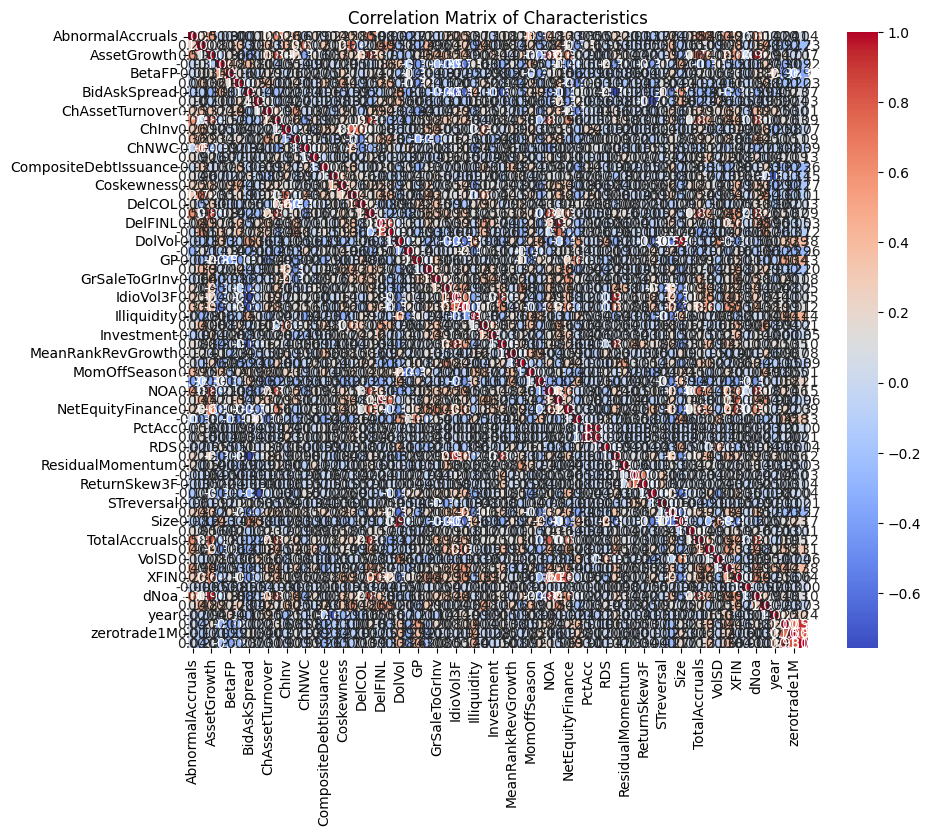

In [26]:
#some characteristics are causing 0 correlation in the IPCA estimation, we will try to identify these characteristics and remove them from the characteristics list, and then we will run the IPCA_Grass_estimation again and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
df_trunc_extended[char_feats_final]
# lets analyise df_trunc_extended[char_feats_final] to identify characteristics with low variance or high correlation with other characteristics, as these can cause issues in the IPCA estimation. We will look at the correlation matrix and the variance of each characteristic, and then we will remove the characteristics that have low variance or high correlation with other characteristics, and then we will run the IPCA_Grass_estimation again and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Correlation matrix
corr_matrix = df_trunc_extended[char_feats_final].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Characteristics")
plt.show()

In [27]:
# # lets drop 1/3 of the char_feats_final as we get ipplosed problems now
# char_feats_reduced = char_feats_final[-33:]
# print(f"Number of characteristics used after reduction: {len(char_feats_reduced)}")
# print("Characteristics used after reduction:", char_feats_reduced)
# # run the IPCA_Grass_estimation with the reduced characteristics list, and see how the performance changes with the number of factors and the window length. We will try with 2,
# # 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# num_factors_list = [1, 2, 4, 8, 16]
# num_iter = 30    
# results_by_factor = {}
# for num_fact in num_factors_list:
#     # we iterate num_iter times for each num_fact to get an average performance
#     all_results = []
#     for i in range(num_iter):
#         print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
#         res = run_ipca_grass(
#             df_trunc=df_trunc_extended,
#             char_feats=char_feats_reduced,
#             num_fact=num_fact,
#             window_len=window_len,
#             max_nan=0.3,
#             max_zero=0.3,
#             min_non_nan_frac=0.7,
#         )
#         all_results.append(res)
#     avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
#     avg_sharpe = np.mean([res["sharpe"] for res in all_results])
#     results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
#     print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# # Lets plot the results
# num_factors = list(results_by_factor.keys())
# avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
# avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(num_factors, avg_r2_oos_values, marker='o')
# plt.title("Average OOS R2 vs Number of Factors (Reduced Characteristics)")
# plt.xlabel("Number of Factors")
# plt.ylabel("Average OOS R2")
# plt.grid()
# plt.subplot(1, 2, 2)
# plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
# plt.title("Average Market-timing Sharpe vs Number of Factors (Reduced Characteristics)")
# plt.xlabel("Number of Factors")
# plt.ylabel("Average Sharpe (annualized)")
# plt.grid()


In [28]:
# # Num iter 30 case for better confidence in the results, as there is some randomness in the IPCA estimation due to the optimization process, and we want to ensure that our results are not just a lucky run. We will try with 1, 2, 4, 8, 16 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# num_iter = 30    
# results_by_factor = {}
# for num_fact in num_factors_list:
#     # we iterate num_iter times for each num_fact to get an average performance
#     all_results = []
#     for i in range(num_iter):
#         print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
#         res = run_ipca_grass(
#             df_trunc=df_trunc_extended,
#             char_feats=char_feats_reduced,
#             num_fact=num_fact,
#             window_len=window_len,
#             max_nan=0.3,
#             max_zero=0.3,
#             min_non_nan_frac=0.7,
#         )
#         all_results.append(res)
#     avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
#     avg_sharpe = np.mean([res["sharpe"] for res in all_results])
#     results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
#     print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# # Lets plot the results
# num_factors = list(results_by_factor.keys())
# avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
# avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(num_factors, avg_r2_oos_values, marker='o')
# plt.title("Average OOS R2 vs Number of Factors (Reduced Characteristics)")
# plt.xlabel("Number of Factors")
# plt.ylabel("Average OOS R2")
# plt.grid()
# plt.subplot(1, 2, 2)
# plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
# plt.title("Average Market-timing Sharpe vs Number of Factors (Reduced Characteristics)")
# plt.xlabel("Number of Factors")
# plt.ylabel("Average Sharpe (annualized)")
# plt.grid()


### Things to clear up - when the sharpe seems to be so volatile, which return subspace structure do we examine to analyze the geometry

#### Things to note during run, char_feat can be high dimensinal but some chars can make the problem illposed, better to understand when and how this happens to avoid this during RFF runs

## ToDo
### Understand the code more -> Incorporate RFF code to the GrassManIPCA.py -> and the compare this 2020-2025 strategy on them both -> then test(same stock universe) for the entire History -> Increase the stock universe and test for entire history

In [39]:
def run_ipca_grass_v2(
    df_trunc,
    char_feats,
    num_fact=2,
    window_len=12,
    max_nan=0.3,
    max_zero=0.3,
    min_non_nan_frac=0.7,
):
    # Build stock-level panel from df_trunc
    df_panel = df_trunc.copy().sort_index()

    # Returns panel (T, N)
    rets_panel = df_panel["ret"].unstack("permno").sort_index()

    # Lagged characteristics panels (T, N) for each feature
    X_list = []
    for col in char_feats:
        x = df_panel[col].unstack("permno").sort_index()
        #x = x.shift(1) # returns were already shifted when we created the df_trunc, so no need to shift again here
        X_list.append(x)

    # Align assets across all panels
    common_assets = rets_panel.columns
    for x in X_list:
        common_assets = common_assets.intersection(x.columns)

    rets_panel = rets_panel[common_assets]
    X_list = [x[common_assets] for x in X_list]

    # Drop assets with too many missing/zeros in returns or any characteristic
    zero_frac_rets = (rets_panel == 0).mean()
    nan_frac_rets  = rets_panel.isna().mean()

    good_assets = (nan_frac_rets <= max_nan) & (zero_frac_rets <= max_zero)
    for x in X_list:
        good_assets &= (x.isna().mean() <= max_nan)
        good_assets &= ((x == 0).mean() <= max_zero)

    rets_panel = rets_panel.loc[:, good_assets]
    X_list = [x.loc[:, good_assets] for x in X_list]

    # Drop early rows with heavy NaNs (burn-in)
    min_non_nan = int(min_non_nan_frac * rets_panel.shape[1])
    valid_time = rets_panel.notna().sum(axis=1) >= min_non_nan
    for x in X_list:
        valid_time &= (x.notna().sum(axis=1) >= min_non_nan)

    rets_panel = rets_panel.loc[valid_time]
    X_list = [x.loc[valid_time] for x in X_list]

    # Impute remaining NaNs with cross-sectional mean
    rets_panel = rets_panel.apply(lambda s: s.fillna(s.mean()), axis=1)
    X_list = [x.apply(lambda s: s.fillna(s.mean()), axis=1) for x in X_list]

    # Standardize characteristics cross-sectionally
    X_list = [(x.sub(x.mean(axis=1), axis=0)).div(x.std(axis=1).replace(0, np.nan), axis=0) for x in X_list]
    X_list = [x.fillna(0.0) for x in X_list]

    # Stack into Z: (T, N, m)
    Z = np.stack([x.to_numpy(dtype=float) for x in X_list], axis=2)
    rets_stock = rets_panel.to_numpy(dtype=float)

    T, N = rets_stock.shape
    preds_stock = np.full_like(rets_stock, np.nan, dtype=float)

    # ── Accumulators for paper diagnostics ────────────────────────────────────
    W_prev          = None   # W from previous window, for subspace stability
    stability_dists = []     # d_proj(V_t, V_{t-1}) per window  (Section 4.2)
    erank_series    = []     # erank(Σ̂_f) per window            (Section 4.1)
    # ─────────────────────────────────────────────────────────────────────────

    for t in range(window_len, T):
        rets_tr = rets_stock[t - window_len:t]
        Z_tr    = Z[t - window_len:t]

        est = GrassmannManifoldIPCAEstimator(
            num_assets=N,
            num_fact=num_fact,
            num_charact=Z.shape[2],
            win_len=rets_tr.shape[0],
        )

        W_t, f_tr, _ = est.fit(
            data=[rets_tr, Z_tr],
            optimizer="ConjugateGradient",
            max_iterations=200,
            verbosity=0,
            log_verbosity=0,
        )

        # ── Metric 1: Subspace stability  (Section 4.2) ───────────────────────
        # d_proj(V_t, V_{t-1}) = ‖W_t W_tᵀ − W_prev W_prevᵀ‖_F
        # W_t has orthonormal columns (lives on Grassmann), so P = W Wᵀ directly.
        # Small value → stable subspace → virtuous complexity.
        # Large value → subspace rotating under sampling → illusory complexity.
        if W_prev is not None:
            P_curr = W_t   @ W_t.T    # (m, m) projection onto current subspace
            P_prev = W_prev @ W_prev.T # (m, m) projection onto previous subspace
            d_proj = np.linalg.norm(P_curr - P_prev, "fro")
            stability_dists.append(d_proj)
        W_prev = W_t
        # ─────────────────────────────────────────────────────────────────────

        # ── Metric 2: Effective rank of fitted factor covariance  (Section 4.1)
        # Σ̂_f = (1/T) Σ_t f̂_t f̂_tᵀ
        # erank(Σ̂_f) = exp(H(p)),  p_i = λ_i / tr(Σ̂_f)  (Shannon entropy)
        # erank ≪ k  → only a few factors active, rest fitting noise.
        # erank → k  → all k factors genuinely identified.
        Sigma_f = (f_tr.T @ f_tr) / f_tr.shape[0]          # (k, k)
        eigvals  = np.linalg.eigvalsh(Sigma_f)               # ascending
        eigvals  = np.maximum(eigvals, 0.0)                  # clip numerical noise
        total    = eigvals.sum()
        if total > 0:
            p        = eigvals / total
            p        = p[p > 0]                              # avoid log(0)
            erank    = np.exp(-np.sum(p * np.log(p)))        # exp(H(p))
        else:
            erank = 1.0
        erank_series.append(erank)
        # ─────────────────────────────────────────────────────────────────────

        # Forecast next factor as historical mean in window
        f_next = f_tr.mean(axis=0)
        Lambda_t = Z[t] @ W_t
        preds_stock[t] = Lambda_t @ f_next

    # ── Evaluate performance on valid rows ────────────────────────────────────
    valid  = ~np.isnan(preds_stock).any(axis=1)
    y_true = rets_stock[valid]
    y_pred = preds_stock[valid]

    mse_oos = np.mean((y_true - y_pred) ** 2)
    r2_oos  = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    # Market-timing Sharpe (annualized for monthly data)
    pos      = y_pred / (np.mean(np.abs(y_pred), axis=1, keepdims=True) + 1e-12)
    port_ret = np.mean(pos * y_true, axis=1)
    sharpe   = np.mean(port_ret) / (np.std(port_ret, ddof=1) + 1e-12) * np.sqrt(12)

    # ── Aggregate paper diagnostics ───────────────────────────────────────────
    # Mean subspace stability: lower is better (stable factor space)
    mean_stability = float(np.mean(stability_dists)) if stability_dists else np.nan

    # Mean effective rank: higher → more genuinely active factors
    mean_erank     = float(np.mean(erank_series))   if erank_series     else np.nan

    # Fraction of windows where effective rank collapsed below 50% of nominal k
    # Flags windows where the optimizer wandered into the noise eigenspace
    erank_collapse_frac = float(np.mean(np.array(erank_series) < 0.5 * num_fact)) \
                          if erank_series else np.nan
    # ─────────────────────────────────────────────────────────────────────────

    print(f"OOS MSE                          : {mse_oos:.6e}")
    print(f"OOS R2                           : {r2_oos:.4f}")
    print(f"Market-timing Sharpe (annualized): {sharpe:.3f}")
    print(f"Mean subspace stability d_proj   : {mean_stability:.4f}  (lower = more stable)")
    print(f"Mean effective rank erank(Σ̂_f)  : {mean_erank:.4f}  (max = {num_fact})")
    print(f"Effective rank collapse fraction : {erank_collapse_frac:.4f}  (fraction of windows erank < k/2)")

    return {
        "r2_oos":               r2_oos,
        "sharpe":               sharpe,
        # ── paper diagnostics ──────────────────────────────────────────────
        "mean_subspace_stability": mean_stability,      # Section 4.2: d_proj series mean
        "stability_dist_series":   stability_dists,     # full per-window series
        "mean_erank":              mean_erank,          # Section 4.1: erank(Σ̂_f) mean
        "erank_series":            erank_series,        # full per-window series
        "erank_collapse_frac":     erank_collapse_frac, # fraction of windows erank < k/2
    }

In [43]:
#lets run the same as above but with window_len = 24, and include more characteristics, and see how the performance changes with the window length and the number of characteristics. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
char_feats_extended = ['Beta', 'skew1', 'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD', 'Mom12m', 'Mom1m', 'Vol1m']
window_len = 24

 # dont truncate while printing columns, we want to see all the columns to decide which ones to include as characteristics
print(df_returns.columns.tolist()) # print columns as list for better readability
# lets pick 50 characteristics with least missing data, and not mostly constant values, and then we will use these characteristics to run the IPCA_Grass_estimation and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Diagnose missing/zeros for all columns
nan_frac = df_returns.isna().mean()
zero_frac = (df_returns == 0).mean()
# Filter columns with low missing/zero fractions
good_cols = (nan_frac <= 0.3) & (zero_frac <= 0.3)
good_cols = good_cols[good_cols].index.tolist()
print(f"Number of good columns: {len(good_cols)}")
print("Good columns:", good_cols)
# We will exclude the 'Price' column and the 'ret' column from the characteristics, and we will also exclude the columns that are not in the good_cols list, and then we will
# run the IPCA_Grass_estimation with the remaining columns as characteristics, and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
excluded_cols = ['Price', 'ret']
char_feats_final = [col for col in good_cols if col not in excluded_cols]
print(f"Number of characteristics used: {len(char_feats_final)}")
print("Characteristics used:", char_feats_final)
# create a df to pass to the function
df_trunc_extended = df_returns[char_feats_final + ['Price']]
# create return column
df_trunc_extended['ret'] = df_trunc_extended.groupby(level=0)['Price'].pct_change()
df_trunc_extended['ret'] = df_trunc_extended.groupby(level=0)['ret'].shift(-1)
df_trunc_extended.dropna(inplace=True)
char_feats_reduced = char_feats_final[-33:]

['AM', 'AOP', 'AbnormalAccruals', 'Accruals', 'AccrualsBM', 'AdExp', 'AnalystRevision', 'AnalystValue', 'AnnouncementReturn', 'AssetGrowth', 'BM', 'BMdec', 'BPEBM', 'Beta', 'BetaFP', 'BetaLiquidityPS', 'BetaTailRisk', 'BidAskSpread', 'BookLeverage', 'BrandInvest', 'CBOperProf', 'CF', 'CPVolSpread', 'Cash', 'CashProd', 'ChAssetTurnover', 'ChEQ', 'ChForecastAccrual', 'ChInv', 'ChInvIA', 'ChNAnalyst', 'ChNNCOA', 'ChNWC', 'ChTax', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'ConvDebt', 'CoskewACX', 'Coskewness', 'CredRatDG', 'CustomerMomentum', 'DebtIssuance', 'DelBreadth', 'DelCOA', 'DelCOL', 'DelDRC', 'DelEqu', 'DelFINL', 'DelLTI', 'DelNetFin', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'DolVol', 'DownRecomm', 'EBM', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'EquityDuration', 'ExchSwitch', 'ExclExp', 'FEPS', 'FR', 'FirmAge', 'ForecastDispersion', 'Frontie

In [44]:
print(len(char_feats_reduced))

33


In [45]:


# RFF transform needs a dense numeric matrix
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1

# Impute missing values cross-sectionally by date, then columnwise fallback
X_chars = X_chars.groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
X_chars = X_chars.fillna(X_chars.median()).fillna(0.0)

GAMMA_VALUES = [0.25, 0.5, 1.0, 2.0]
N_FEATURES_EFF = [32,  512, 4096, 16372, 65536]
window_lens = [6, 12, 24]
num_factors_list = [ 2, 4, 8, 16]
num_iter_rff = 100
results_by_factor_rff = {} 
#lets run for diffenre gamma, n_features, and num_factors, and window_len, and store all the resuts in some dataframe
# for some combinations, run_ipca_grass_v2 might throw error due to convergence issues in the optimization, we will catch these errors and store the results as NaN for those combinations, and then we will analyze the results later to see if there are any patterns in the convergence issues with respect to gamma, n_features, num_factors, and window_len.
for gamma, n_features, window_len, num_fact in itertools.product(GAMMA_VALUES, N_FEATURES_EFF, window_lens, num_factors_list):
    all_results = []
    for i in range(num_iter_rff):
        print(f"\nGamma: {gamma}, N_features: {n_features}, Window_len: {window_len}, Num_factors: {num_fact}, Run {i+1}/{num_iter_rff}")
        try:
            # Create RFF transformer for current gamma and n_features
            rff_transformer = RandomFourierFeatures(gamma=gamma, n_features=n_features)
            # Apply RFF transformation to characteristics
            X_rff = rff_transformer.transform(X_chars, seed = i)
            # Create a new DataFrame for the RFF-transformed features
            char_cols_rff = [f"RFF_{j}" for j in range(X_rff.shape[1])]
            df_rff = pd.DataFrame(X_rff, index=X_chars.index, columns=char_cols_rff)
            # Combine with price and return columns
            df_combined = pd.concat([df_trunc_extended[['Price', 'ret']], df_rff], axis=1)
            # Run IPCA Grassmann estimation on the combined DataFrame
            res = run_ipca_grass_v2(
                df_trunc=df_combined,
                char_feats=char_cols_rff,
                num_fact=num_fact,
                window_len=window_len,
                max_nan=0.3,
                max_zero=0.3,
                min_non_nan_frac=0.7,
            )
        except Exception as e:
            print(f"Error during run: {e}")
            res = {
                "r2_oos": np.nan,
                "sharpe": np.nan,
                "mean_subspace_stability": np.nan,
                "mean_erank": np.nan,
                "erank_collapse_frac": np.nan,
            }
        all_results.append(res)
    avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
    avg_sharpe = np.mean([res["sharpe"] for res in all_results])
    avg_stability = np.mean([res["mean_subspace_stability"] for res in all_results])
    avg_erank = np.mean([res["mean_erank"] for res in all_results])
    avg_erank_collapse_frac = np.mean([res["erank_collapse_frac"] for res in all_results])
    results_by_factor_rff[(gamma, n_features, window_len, num_fact)] = {
        "avg_r2_oos": avg_r2_oos,
        "avg_sharpe": avg_sharpe,
        "avg_stability": avg_stability,
        "avg_erank": avg_erank,
        "avg_erank_collapse_frac": avg_erank_collapse_frac,
    }
    print(f"\nGamma: {gamma}, N_features: {n_features}, Window_len: {window_len}, Num_factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}, Average Stability: {avg_stability:.4f}, Average Erank: {avg_erank:.4f}, Average Erank Collapse Fraction: {avg_erank_collapse_frac:.4f}") 
    


Gamma: 0.25, N_features: 32, Window_len: 6, Num_factors: 2, Run 1/100
OOS MSE                          : 7.436020e-02
OOS R2                           : -0.1213
Market-timing Sharpe (annualized): -0.444
Mean subspace stability d_proj   : 1.8564  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.5561  (max = 2)
Effective rank collapse fraction : 0.0000  (fraction of windows erank < k/2)

Gamma: 0.25, N_features: 32, Window_len: 6, Num_factors: 2, Run 2/100
OOS MSE                          : 9.203401e-02
OOS R2                           : -0.3878
Market-timing Sharpe (annualized): 0.273
Mean subspace stability d_proj   : 1.8314  (lower = more stable)
Mean effective rank erank(Σ̂_f)  : 1.4307  (max = 2)
Effective rank collapse fraction : 0.0000  (fraction of windows erank < k/2)

Gamma: 0.25, N_features: 32, Window_len: 6, Num_factors: 2, Run 3/100
OOS MSE                          : 6.872916e-02
OOS R2                           : -0.0363
Market-timing Sharpe (annualized): 0.309


KeyboardInterrupt: 

In [49]:
results_by_factor_rff_df    = pd.DataFrame.from_dict(results_by_factor_rff, orient='index')
results_by_factor_rff_df.index.names = ['gamma', 'n_features', 'window_len', 'num_fact']
results_by_factor_rff_df.reset_index(inplace=True)
print(len(results_by_factor_rff_df))

17


In [53]:
#lets drop num_fact = 16 from the results as we have convergence issues for many combinations of gamma, n_features, and window_len when num_fact = 16, and then we will analyze the results for num_fact = 2, 4, 8 to see if there are any patterns in the performance with respect to gamma, n_features, and window_len.
results_by_factor_rff_df_filtered = results_by_factor_rff_df[results_by_factor_rff_df['num_fact'] != 16]
print(len(results_by_factor_rff_df_filtered))
if 'avg_r2_oos' in results_by_factor_rff_df_filtered.columns:
    results_by_factor_rff_df_filtered.drop(columns = ['avg_r2_oos'], inplace = True)

13


,gamma,n_features,window_len,num_fact,avg_sharpe,avg_stability,avg_erank,avg_erank_collapse_frac
0,0.25,32,6,2,0.432533,1.845454,1.515497,0.000000
1,0.25,32,6,4,0.463791,2.656080,2.211144,0.339811
2,0.25,32,6,8,0.415147,3.734045,2.682717,0.985660
4,0.25,32,12,2,0.119210,1.857108,1.471245,0.000000
5,0.25,32,12,4,0.308521,2.642112,2.457820,0.217660
6,0.25,32,12,8,0.282943,3.725807,3.415067,0.700213
8,0.25,32,24,2,0.185450,1.850485,1.401947,0.000000
9,0.25,32,24,4,0.279637,2.640960,2.330207,0.306571
10,0.25,32,24,8,0.257682,3.718592,3.826203,0.527714
12,0.25,512,6,2,0.417169,1.991828,1.616977,0.000000


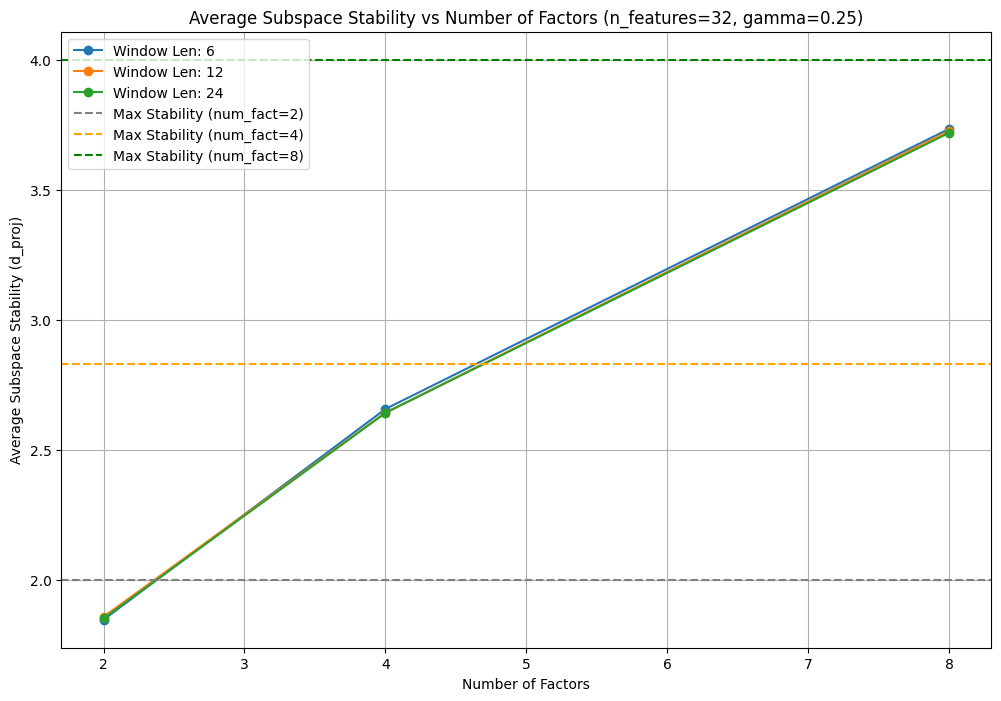

In [55]:
#lets add a columns max_avg_stability which is sqrt(2*num_fact)
results_by_factor_rff_df_filtered['max_avg_stability'] = np.sqrt(2 * results_by_factor_rff_df_filtered['num_fact'])
#lets plot acg_stabilty vs num_fact for each window_len, when n_features = 32, gamma = 0.25

plt.figure(figsize=(12, 8))
for window_len in window_lens:
    subset = results_by_factor_rff_df_filtered[
        (results_by_factor_rff_df_filtered['window_len'] == window_len) &
        (results_by_factor_rff_df_filtered['n_features'] == 32) &
        (results_by_factor_rff_df_filtered['gamma'] == 0.25)
    ]
    plt.plot(subset['num_fact'], subset['avg_stability'], marker='o', label=f'Window Len: {window_len}')
plt.axhline(y=np.sqrt(2*2), color='gray', linestyle='--', label='Max Stability (num_fact=2)')
plt.axhline(y=np.sqrt(2*4), color='orange', linestyle='--', label='Max Stability (num_fact=4)')
plt.axhline(y=np.sqrt(2*8), color='green', linestyle='--', label='Max Stability (num_fact=8)')
plt.title('Average Subspace Stability vs Number of Factors (n_features=32, gamma=0.25)')
plt.xlabel('Number of Factors')
plt.ylabel('Average Subspace Stability (d_proj)')
plt.legend()
plt.grid()
plt.show()

### Stability of subspaces is at max possible value for any number of factors

In [2]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

import numpy as np
from matplotlib import pyplot as plt

import autograd.numpy as anp
from pymanopt import Problem
from pymanopt.manifolds import Grassmann
from pymanopt.function import autograd as pymanopt_autograd
from pymanopt.optimizers import ConjugateGradient, SteepestDescent, TrustRegions

from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
for p in [ROOT_DIR, ROOT_DIR / "src"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from src.IPCA_Grass_estimator import GrassmannManifoldIPCAEstimator
from src.backtest_GRASS_IPCA import run_ipca_grass_v2
from src.rff import RandomFourierFeatures

In [60]:
df_trunc.index
# find how many permno we have in the df_trunc
permnos = df_trunc.index.get_level_values('permno').unique()
print(f"Number of unique permnos: {len(permnos)}")

Number of unique permnos: 24


In [68]:
print(len(char_feats_reduced)) # dont truncate this as we want to see all the characteristics to decide which ones to include in the analysis


33


## Updated grassman

In [4]:
#chars restructuring
#These charactereistics dont have much variance in them, making the problem illposed, lets load the return data for these stock from 2020 - 2026 and create our our characteristics using the return data, and then we will use the IPCA approach to predict the return of stocks. We will perform the same for a bigger period later

df_returns = pd.read_excel("df_data_all_stocks_2020_onwards.xlsx")
df_returns.rename(columns={'yyyymm': 'date'}, inplace=True)
df_returns.head()
# lets pivot the table to have permno and date as index, and all the columns as values, and then we will use this data to create our characteristics for the IPCA approach. We will use the return data to create momentum and volatility characteristics for each stock, and then we will use these characteristics to predict the return of stocks using the IPCA approach.

df_returns = df_returns.pivot_table(index=['permno', 'date'], values=[col for col in df_returns.columns if col not in ['permno', 'date']], aggfunc='first')
df_returns.head()

#lets see how the data looks like for a few more columns, thigs arebeing truncated in.head()

# we need to see more columns i.e, horizontal view
with pd.option_context("display.max_columns", None, "display.width", 50, "display.max_colwidth", None):
    print(df_returns.loc[10104].head(10).to_string())
char_feats = [ 'Beta', 'skew1',  'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD']
# lets work with just these 4 features for now, we will extend to all the features later
df_trunc = df_returns[char_feats + ['Price']]
#create a return column from the price, shift the returns by 1 so that there is no look ahead

df_trunc['ret'] = df_trunc.groupby(level=0)['Price'].pct_change()
df_trunc['ret'] = df_trunc['ret'].shift(-1)
df_trunc.dropna(inplace=True)
df_trunc.head()

#lets run the same as above but with window_len = 24, and include more characteristics, and see how the performance changes with the window length and the number of characteristics. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
char_feats_extended = ['Beta', 'skew1', 'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD', 'Mom12m', 'Mom1m', 'Vol1m']
window_len = 24

 # dont truncate while printing columns, we want to see all the columns to decide which ones to include as characteristics
print(df_returns.columns.tolist()) # print columns as list for better readability
# lets pick 50 characteristics with least missing data, and not mostly constant values, and then we will use these characteristics to run the IPCA_Grass_estimation and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Diagnose missing/zeros for all columns
nan_frac = df_returns.isna().mean()
zero_frac = (df_returns == 0).mean()
# Filter columns with low missing/zero fractions
good_cols = (nan_frac <= 0.3) & (zero_frac <= 0.3)
good_cols = good_cols[good_cols].index.tolist()
print(f"Number of good columns: {len(good_cols)}")
print("Good columns:", good_cols)
# We will exclude the 'Price' column and the 'ret' column from the characteristics, and we will also exclude the columns that are not in the good_cols list, and then we will
# run the IPCA_Grass_estimation with the remaining columns as characteristics, and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
excluded_cols = ['Price', 'ret']
char_feats_final = [col for col in good_cols if col not in excluded_cols]
print(f"Number of characteristics used: {len(char_feats_final)}")
print("Characteristics used:", char_feats_final)
# create a df to pass to the function
df_trunc_extended = df_returns[char_feats_final + ['Price']]
# create return column
df_trunc_extended['ret'] = df_trunc_extended.groupby(level=0)['Price'].pct_change()
df_trunc_extended['ret'] = df_trunc_extended['ret'].shift(-1)
df_trunc_extended.dropna(inplace=True)

# lets drop 1/3 of the char_feats_final as we get ipplosed problems now
char_feats_reduced = char_feats_final[-33:]
print(f"Number of characteristics used after reduction: {len(char_feats_reduced)}")
print("Characteristics used after reduction:", char_feats_reduced)

                  AM  AOP  AbnormalAccruals  Accruals  AccrualsBM     AdExp  AnalystRevision  AnalystValue  AnnouncementReturn  AssetGrowth  BM     BMdec     BPEBM      Beta    BetaFP  BetaLiquidityPS  BetaTailRisk  BidAskSpread  BookLeverage  BrandInvest  CBOperProf        CF  CPVolSpread      Cash  CashProd  ChAssetTurnover      ChEQ  ChForecastAccrual     ChInv   ChInvIA  ChNAnalyst   ChNNCOA     ChNWC     ChTax  ChangeInRecommendation  CitationsRD  CompEquIss  CompositeDebtIssuance  ConsRecomm  ConvDebt  CoskewACX  Coskewness  CredRatDG  CustomerMomentum  DebtIssuance  DelBreadth    DelCOA    DelCOL    DelDRC    DelEqu   DelFINL  DelLTI  DelNetFin  DivInit  DivOmit  DivSeason  DivYieldST     DolVol  DownRecomm       EBM        EP  EarnSupBig  EarningsConsistency  EarningsForecastDisparity  EarningsStreak  EarningsSurprise    EntMult  EquityDuration  ExchSwitch  ExclExp  FEPS  FR  FirmAge  ForecastDispersion  Frontier       GP   GrAdExp   GrLTNOA  GrSaleToGrInv  GrSaleToGrOverhead  

In [6]:
## Same run as 2 cells above, but runnign with grassman_v2, for subspace stability and effective rank diagnostics, 


# RFF transform needs a dense numeric matrix
char_feats_reduced = char_feats_final[-33:]
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1

# Impute missing values cross-sectionally by date, then columnwise fallback
X_chars = X_chars.groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
X_chars = X_chars.fillna(X_chars.median()).fillna(0.0)

GAMMA = 0.25
window_len = 12
N_FEATURES_RFF = [128, 1024, 4096, 16384]
num_factors_list = [2, 4, 8, 12]

num_iter_rff = 4
results_by_factor_rff = {} 
# lets run for each num_factor and N_FEATURES_RFF combination, and store the results in a dictionary
for num_fact in num_factors_list:
    for n_feat in N_FEATURES_RFF:
        print(f"\nRunning for num_fact: {num_fact}, N_FEATURES: {n_feat}")
        
        
        all_results = []
        for i in range(num_iter_rff):
            rff = RandomFourierFeatures(n_features=int(n_feat / 2), gamma=GAMMA)
            rff_data = rff.transform(X_chars, seed=i)
            rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
            rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)
            df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
            print(f"Run {i+1}/{num_iter_rff} for num_fact: {num_fact}, N_FEATURES: {n_feat}")
            res = run_ipca_grass_v2(
                df_trunc=df_trunc_rff,
                char_feats=rff_cols,
                num_fact=num_fact,
                window_len=window_len,
                max_nan=0.3,
                max_zero=0.3,
                min_non_nan_frac=0.7,
            )
            all_results.append(res)

        results_by_factor_rff[(num_fact, n_feat)] = {
            "avg_r2_oos": np.mean([r["r2_oos"] for r in all_results]),
            "avg_sharpe": np.mean([r["sharpe"] for r in all_results]),
            "avg_subspace_stability": np.mean([r["mean_subspace_stability"] for r in all_results]),
            "avg_max_principal_angle": np.mean([r["mean_max_principal_angle"] for r in all_results]),
            "avg_mean_principal_angle": np.mean([r["mean_mean_principal_angle"] for r in all_results]),
            "avg_geodesic_accel": np.mean([r["mean_geodesic_accel"] for r in all_results]),
            "avg_erank": np.mean([r["mean_erank"] for r in all_results]),
            "avg_erank_collapse": np.mean([r["erank_collapse_frac"] for r in all_results]),
            "avg_spectral_gap": np.mean([r["mean_spectral_gap"] for r in all_results]),
            "stability_dist_series": [r["stability_dist_series"] for r in all_results],
            "principal_angles_series": [r["principal_angles_series"] for r in all_results],
            "geodesic_accel_series": [r["geodesic_accel_series"] for r in all_results],
            "erank_series": [r["erank_series"] for r in all_results],
            "spectral_gap_series": [r["spectral_gap_series"] for r in all_results],
        }
        all_results.append(res)
results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)


Running for num_fact: 2, N_FEATURES: 128
Run 1/4 for num_fact: 2, N_FEATURES: 128
  Grassmann-IPCA Backtest Results

── Performance ──────────────────────────────────────────────
  OOS MSE                              : 8.161055e-02
  OOS R²                               : -0.1015
  Market-timing Sharpe (annualised)    : 0.603

── Metric 1 : Projection distance d_proj ────────────────────
  Mean d_proj                          : 1.9049  (lower = more stable)

── Metric 2 : Principal angles (NEW) ────────────────────────
  Mean max angle   (rad)               : 1.4196  (worst-case dir drift; 0 = stable)
  Mean mean angle  (rad)               : 1.3059  (avg dir drift; 0 = stable)

── Metric 3 : Geodesic acceleration (NEW) ───────────────────
  Mean |Δd_proj|                       : 0.0806  (near 0 = converging subspace)

── Metric 4 : Effective rank erank(Σ̂_f) ────────────────────
  Mean erank                           : 1.5582  (max = 2)
  erank collapse fraction              : 0.0000

avg_r2_oos avg_sharpe avg_subspace_stability  \
2  128      -0.041348   0.489711               1.914936   
   1024     -0.315336   0.428151               1.988989   
   4096     -0.070154   0.183109               1.998844   
   16384    -0.310003    0.17813               1.999817   
4  128      -0.016144    0.19014               2.743867   
   1024      0.005089    0.48001               2.821579   
   4096      -0.00193   0.403964               2.827018   
   16384    -0.018022   0.232765               2.828075   
8  128       -0.05725   0.145662               3.869828   
   1024     -0.023696   0.180117               3.984314   
   4096     -0.199905   0.322555               3.996086   
   16384    -0.020957   0.347575               3.999022   
12 128   -8581.634539   0.219028               4.668361   
   1024     -5.437109  -0.014852               4.870111   
   4096     -0.356657   0.254024               4.891842   
   16384    -0.607928  -0.320537               4.897172   

         avg_max_principal_angle avg_mean_principal_angle avg_geodesic_accel  \
2  128                  1.438199                 1.323382           0.063196   
   1024                 1.530562                 1.487301            0.00911   
   4096                 1.559537                 1.544013           0.000899   
   16384                1.565593                 1.559838           0.000159   
4  128                  1.527604                 1.366013           0.029004   
   1024                 1.560413                 1.513979           0.002877   
   4096                 1.565223                  1.54474           0.000582   
   16384                1.568116                 1.557802           0.000123   
8  128                  1.547743                 1.353766           0.019969   
   1024                 1.562878                 1.496693            0.00313   
   4096                 1.567481                 1.534011           0.000792   
   16384                1.568771                  1.55225           0.000182   
12 128                  1.553363                 1.307254           0.027495   
   1024                  1.56442                 1.479393           0.004086   
   4096                 1.567688                 1.525543           0.000891   
   16384                1.569346                 1.548026           0.000218   

         avg_erank avg_erank_collapse avg_spectral_gap  \
2  128    1.545786                0.0         0.249825   
   1024   1.667417                0.0         0.339631   
   4096   1.658642                0.0         0.329266   
   16384  1.628146                0.0         0.310079   
4  128    2.567361           0.143617         0.070081   
   1024   2.671335            0.12766         0.082004   
   4096   2.686961           0.111702         0.074868   
   16384  2.663231           0.148936         0.080811   
8  128    3.549912           0.670213         0.004472   
   1024   3.678091           0.601064         0.006078   
   4096   3.541407            0.62766         0.005867   
   16384  3.551572           0.675532         0.005929   
12 128    3.696099           0.973404         0.000078   
   1024   3.798171           0.984043         0.000086   
   4096   3.696478           0.978723         0.000089   
   16384  3.738335           0.978723         0.000099   

                                      stability_dist_series  \
2  128    [[1.9212787025776599, 1.8236631873282056, 1.90...   
   1024   [[1.9927882260465446, 1.9934520356913032, 1.94...   
   4096   [[1.9984622018242821, 1.9997634109045395, 1.99...   
   16384  [[1.9999206949491741, 1.9996335920772421, 1.99...   
4  128    [[2.7367258882059633, 2.774896936953015, 2.703...   
   1024   [[2.825535519983501, 2.8204235313530073, 2.823...   
   4096   [[2.826513900081889, 2.8270396031934575, 2.827...   
   16384  [[2.828100731252515, 2.828140627534561, 2.8282...   
8  128    [[3.864395342692587, 3.8908287383388593, 3.858...   
   1024   [[3.983667202194511

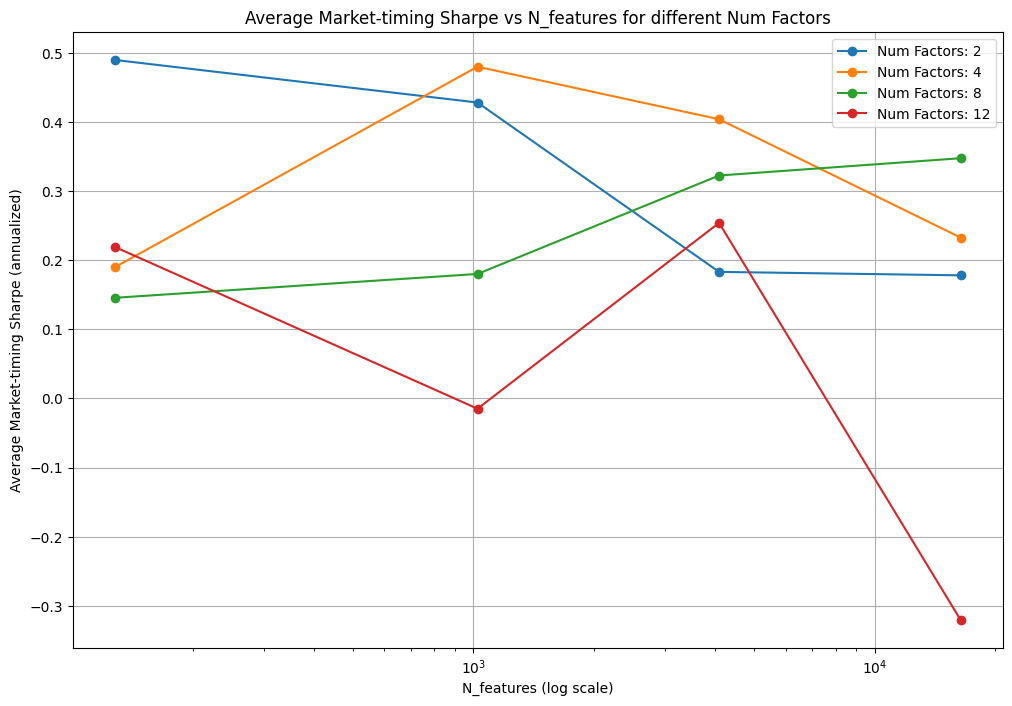

In [7]:
# lets plot sharpe vs N_features, for each num_fact(one curve with a color for each num_fact)
plt.figure(figsize=(12, 8))
for num_fact in num_factors_list:
    subset = results_rff_df.loc[results_rff_df.index.get_level_values(0) == num_fact]
    plt.plot(subset.index.get_level_values(1), subset["avg_sharpe"], marker='o', label=f'Num Factors: {num_fact}')
plt.xscale('log')
plt.title('Average Market-timing Sharpe vs N_features for different Num Factors')
plt.xlabel('N_features (log scale)')
plt.ylabel('Average Market-timing Sharpe (annualized)')
plt.legend()
plt.grid()
plt.show()


In [8]:
# store the reults in a pickle file
import pickle
with open("results_rff_Z0_diffFactors.pkl", "wb") as f:
    pickle.dump(results_by_factor_rff, f)
